# Reverse-Engineering a Home Run: An Inverse Ballistics Calculator

## Introduction

A radar/camera rig like TrackMan or Rapsodo will hand a hitter exact numbers for **exit velocity** (how fast the ball leaves the bat), **launch angle** (how steeply it comes off the bat), and **swing speed** (how fast the bat itself is moving at contact). Those systems cost tens of thousands of dollars and live in college programs and MLB parks, not on a random weeknight beer-league field.

But an amateur player usually *does* have a few things: a rough sense of how far the ball traveled, a rough sense of how long it hung in the air, and whatever the wind was doing. That's enough to work the problem backwards.

Most swing-analysis tools are **forward simulators**: you feed in exit velocity and launch angle, and they tell you how far the ball goes. This project does the reverse. It's an **inverse ballistics calculator**: feed in what you observed from the field (hang time, estimated distance, wind, hit direction, pitch speed, and your bat's specs), and it solves for the swing metrics that would have produced that flight.

I hit a home run recently and don't have a radar gun, so it's the running example for this whole post:

- Bat: 34", 31 oz, balanced maple bat (a Texas Timber TX73)
- Pitch: a low curveball, roughly 55-60 mph
- Hang time: about 4.25 seconds
- Direction: left-center
- Wind: 15 mph, blowing from the right field foul pole toward the left field foul pole
- The fence in that part of the park sits at 370 ft; I estimate the ball carried 390-400 ft

By the end, we'll have an estimated exit velocity, launch angle, and swing speed for that specific swing.

## Purpose

Given:

- an estimated hang time and travel distance
- wind speed and direction
- the direction the ball was hit
- pitch speed
- bat weight, length, and balance

...solve for exit velocity, launch angle, and swing speed.

The solve happens in two independent stages:

1. **Ballistics stage** - forward-simulate a batted ball's flight under gravity, drag, and wind, then search for the exit velocity and launch angle that reproduce the *observed* distance and hang time.
2. **Collision stage** - take the exit velocity from stage 1, combine it with the pitch speed and a simplified model of the bat as a pivoting rod, and solve algebraically for the bat swing speed that would produce it.

Both stages lean on simplifying assumptions rather than a full 3D flight/collision simulation - the goal is a reasonable ballpark estimate (pun intended), not a TrackMan replacement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

MPH_TO_MS = 0.44704
FT_TO_M = 0.3048
IN_TO_M = 0.0254
OZ_TO_KG = 0.0283495

### The Ball Flight Model

Between contact and landing, a batted ball is subject to gravity, aerodynamic drag, and the Magnus lift force generated by backspin. Solving for the actual spin rate isn't possible here - that would take a third independent observation beyond just distance and hang time - so this model assumes a fixed backspin rather than solving for it. MLB home runs average around 2500 rpm of backspin (see [Alan Nathan's work](http://baseball.physics.illinois.edu/carry.html)), but that reflects pros with swing planes tuned specifically to generate backspin. A 33-year-old beer-league hitter squaring up a low pitch still generates real backspin - a low pitch met with a level-ish swing does that almost for free - just less consistently than a pro's. **2200 rpm** is used here as a more realistic number for that context.

The drag force opposes the ball's velocity *relative to the air* (so a headwind or tailwind matters), with magnitude proportional to the square of that relative speed:

$$\vec F_{drag} = -\frac12 C_d \rho A |\vec v_{rel}|\, \vec v_{rel}$$

The Magnus force is perpendicular to that same relative velocity, and its strength depends on the **spin factor** $S = r\omega/v$ (ball radius times spin rate, divided by speed). A simple $C_l \approx S$ approximation is sometimes cited for baseball's typical spin range, but checking it against a well-known reference trajectory (100 mph, 29°, 2200 rpm should carry a bit over 400 ft) showed it overshoots by a wide margin. The **Sawicki-Hubbard-Stronge** model, standard in sports-ball aerodynamics, matches that reference much more closely:

$$C_l = \frac{1}{2 + 1/S}$$

$$\vec F_{magnus} = \frac12 C_l \rho A |\vec v_{rel}|\, \vec u$$

where $\vec u$ is $\vec v_{rel}$ rotated 90°. Combined with gravity, that gives the ball's acceleration at any instant, which we integrate forward in small time steps until it returns to ground level.

In [2]:
# baseball + air constants
g = 9.81                       # m/s^2
m_ball = 0.145                 # kg, ~5.125 oz regulation ball
d_ball = 0.0749                # m, ~2.9 in diameter
A = np.pi * (d_ball / 2) ** 2  # cross-sectional area, m^2
rho = 1.225                    # kg/m^3, sea-level air density
Cd = 0.30                      # drag coefficient, typical for a baseball in flight

backspin_rpm = 2200                        # realistic beer-league backspin, below the ~2500 rpm MLB average
spin_omega = backspin_rpm * 2 * np.pi / 60  # rad/s


def simulate_trajectory(v0_ms, launch_angle_deg, headwind_ms, dt=0.005):
    """Integrate flight until the ball returns to y=0. Returns (distance_m, time_s)."""
    theta = np.radians(launch_angle_deg)
    vx, vy = v0_ms * np.cos(theta), v0_ms * np.sin(theta)
    x, y, t = 0.0, 0.0, 0.0
    while True:
        vx_rel, vy_rel = vx - headwind_ms, vy
        speed_rel = np.hypot(vx_rel, vy_rel)
        spin_factor = (d_ball / 2) * spin_omega / speed_rel  # S = r*omega/v
        Cl = 1 / (2 + 1 / spin_factor)                        # Sawicki-Hubbard-Stronge lift model
        drag = 0.5 * Cd * rho * A * speed_rel / m_ball
        lift = 0.5 * Cl * rho * A * speed_rel / m_ball
        vx += (-drag * vx_rel - lift * vy_rel) * dt
        vy += (-g - drag * vy_rel + lift * vx_rel) * dt
        x += vx * dt
        y += vy * dt
        t += dt
        if y <= 0 and t > dt * 2:
            return x, t

### Wind: Turning a Compass Bearing Into a Headwind

"15 mph from the right field pole to the left field pole" isn't directly usable - what matters for distance is only the wind's component *along the ball's flight path*. The rest is a crosswind that pushes the ball sideways without adding or subtracting much hang distance, so it's ignored here (another simplifying assumption - it costs us lateral accuracy, not distance/time accuracy).

There's a neat geometric shortcut available at almost any ballpark: the two foul poles are (roughly) equidistant from home plate. That means a wind blowing in a straight line from one foul pole to the other is running exactly perpendicular to a ball hit to dead center - a pure crosswind for that ball. For a ball pulled or pushed off center, that same wind picks up a tailwind or headwind component proportional to how far off center the ball was hit.

Measuring both the wind direction and the hit direction as an angle off dead center (positive toward left field), the along-path component works out to a simple projection:

$$w_\parallel = w\cos(\theta_w - \theta_h)$$

where $w$ is wind speed, $\theta_w$ is the direction the wind blows toward (in field-angle terms), and $\theta_h$ is the hit direction. A pole-to-pole wind is $\theta_w = 90°$; dead center is $\theta_h = 0°$.

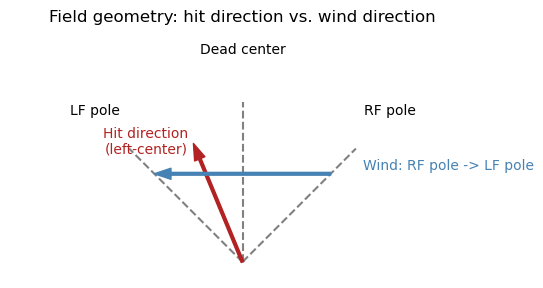

In [3]:
def headwind_component(hit_angle_deg, wind_speed_ms, wind_dir_deg):
    """Positive = tailwind (helps distance), negative = headwind."""
    return wind_speed_ms * np.cos(np.radians(wind_dir_deg - hit_angle_deg))


fig, ax = plt.subplots(figsize=(6, 6))
R = 1.0
# Screen x = -R*sin(angle) so the picture matches a bird's-eye view from home
# plate (left field on the left, right field on the right), even though
# "angle" itself is measured positive toward left field.
for angle, label in [(-45, "RF pole"), (45, "LF pole"), (0, "Dead center")]:
    rad = np.radians(angle)
    x, y = -R * np.sin(rad), R * np.cos(rad)
    ax.plot([0, x], [0, y], color="gray", linestyle="--")
    ax.annotate(label, (x * 1.3, y * 1.3), ha="center")

hit_rad = np.radians(22.5)
hx, hy = -0.8 * np.sin(hit_rad), 0.8 * np.cos(hit_rad)
ax.annotate("", xy=(hx, hy), xytext=(0, 0),
            arrowprops=dict(color="firebrick", width=2, headwidth=8))
ax.annotate("Hit direction\n(left-center)", (-0.34, 0.68), color="firebrick", ha="right")

ax.annotate("", xy=(-0.55, 0.55), xytext=(0.55, 0.55),
            arrowprops=dict(color="steelblue", width=2, headwidth=8))
ax.annotate("Wind: RF pole -> LF pole", (0.75, 0.58), color="steelblue", ha="left")

ax.set_xlim(-1.45, 1.45)
ax.set_ylim(-0.1, 1.45)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Field geometry: hit direction vs. wind direction")
plt.show()

### Solving the Inverse Ballistics Problem

`simulate_trajectory` answers the forward question: given an exit velocity and launch angle, how far does the ball go and how long does it hang? We need the reverse: given an observed distance and hang time, what exit velocity and launch angle would produce them?

That's two equations (distance matches, time matches) in two unknowns ($v_0$, $\theta$), which is exactly the shape `scipy.optimize.fsolve` is built for - no need for a full grid search.

In [4]:
def solve_launch_conditions(observed_distance_m, observed_time_s, headwind_ms):
    def residuals(params):
        v0, angle = params
        dist, t = simulate_trajectory(v0, angle, headwind_ms)
        return [dist - observed_distance_m, t - observed_time_s]

    # A fixed start near typical home-run exit velocity/angle - the no-drag,
    # no-lift heuristic used before adding Magnus lift is too far off to converge.
    v0, angle = fsolve(residuals, [45, 20])
    return v0, angle

### From Exit Velocity to Swing Speed: A Simplified Bat-Ball Collision

Exit velocity alone doesn't tell us how fast the bat was moving - that also depends on the pitch speed and the bat itself. A bat doesn't translate straight through the ball the way a free mass would; it pivots around the hands, so the mass that "matters" at the point of contact isn't the bat's full weight. It's an **effective mass**, set by the bat's moment of inertia about the hands and how far out the ball actually hits it:

$$M = I / r^2$$

A uniform rod is a poor stand-in for a real bat - a wood bat is closer to a tapered cone, thin at the handle and thick at the barrel, so more of its mass sits farther from the pivot than a uniform rod would suggest, which raises $I$ for the same total weight and length. Modeling the bat as a solid cone whose radius grows linearly from handle to barrel (a typical handle-to-barrel diameter ratio of about 1:2.5) captures that without any new inputs: it only needs the bat's mass, length, and that fixed taper ratio, integrated numerically for $I$. A `balance_factor` still scales the result up or down for a bat that's more end-loaded or more evenly weighted than that typical taper (1.0 for a bat like the TX73, about as balanced as a wood bat gets). Contact is assumed to happen at the "sweet spot," about 6 inches in from the barrel tip, so $r = L - 6\text{in}$.

With that effective mass in hand, the bat-ball collision is just a 1D collision problem: ball and bat approach each other, collide with some coefficient of restitution $e$ (a fixed, simplified value here - in reality it varies with impact speed and bat model), and the ball leaves at:

$$v_0 = \dfrac{(e M - m)v_p + M(1+e)v_b}{m + M}$$

where $v_p$ is pitch speed and $v_b$ is bat (swing) speed at the contact point. We already have $v_0$ from the ballistics solve, so this just needs to be inverted for $v_b$:

$$v_b = \dfrac{v_0(m + M) - (eM - m)v_p}{M(1+e)}$$

In [5]:
def bat_moment_of_inertia(bat_mass_kg, bat_length_m, balance_factor=1.0, taper_ratio=2.5, n=400):
    x = np.linspace(0, bat_length_m, n)                      # 0 = handle/pivot, L = barrel tip
    radius = 1 + (taper_ratio - 1) * (x / bat_length_m)       # relative radius, handle=1, barrel=taper_ratio
    linear_density = radius ** 2                              # mass per unit length ~ cross-sectional area
    mass_dist = linear_density / np.trapz(linear_density, x) * bat_mass_kg  # normalize to true bat mass
    return balance_factor * np.trapz(mass_dist * x ** 2, x)


def bat_effective_mass(bat_mass_kg, bat_length_m, balance_factor=1.0, contact_offset_m=6 * IN_TO_M):
    I = bat_moment_of_inertia(bat_mass_kg, bat_length_m, balance_factor)
    r = bat_length_m - contact_offset_m
    return I / r ** 2


def swing_speed_from_exit_velo(v0_ms, v_pitch_ms, M_eff_kg, e=0.5):
    numerator = v0_ms * (m_ball + M_eff_kg) - (e * M_eff_kg - m_ball) * v_pitch_ms
    return numerator / (M_eff_kg * (1 + e))

## Example: My Home Run

Now the actual swing. I only trust my distance estimate to within about 10 ft, so I'll run the whole pipeline for both ends of that range (390 ft and 400 ft) rather than pretending to more precision than a pair of eyeballs in the stands actually provides.

In [6]:
hang_time = 4.25
hit_angle = 22.5          # left-center, degrees off dead center toward LF
wind_speed = 15 * MPH_TO_MS
wind_dir = 90             # RF pole -> LF pole is a pure lateral bearing, see derivation above
headwind = headwind_component(hit_angle, wind_speed, wind_dir)
print(f"Along-path wind component: {headwind / MPH_TO_MS:.1f} mph "
      f"({'tailwind' if headwind > 0 else 'headwind'})")

bat_mass = 31 * OZ_TO_KG
bat_length = 34 * IN_TO_M
M_eff = bat_effective_mass(bat_mass, bat_length, balance_factor=1.0)  # "balanced" bat
v_pitch = 57.5 * MPH_TO_MS

results = []
for distance_ft in (390, 400):
    dist_m = distance_ft * FT_TO_M
    v0, angle = solve_launch_conditions(dist_m, hang_time, headwind)
    v_bat = swing_speed_from_exit_velo(v0, v_pitch, M_eff)
    results.append((distance_ft, v0, angle, v_bat))
    print(f"{distance_ft} ft -> exit velo {v0 / MPH_TO_MS:5.1f} mph, "
          f"launch angle {angle:4.1f} deg, swing speed {v_bat / MPH_TO_MS:5.1f} mph")

Along-path wind component: 5.7 mph (tailwind)
390 ft -> exit velo  96.0 mph, launch angle 23.6 deg, swing speed  69.1 mph
400 ft -> exit velo  98.5 mph, launch angle 22.7 deg, swing speed  71.2 mph


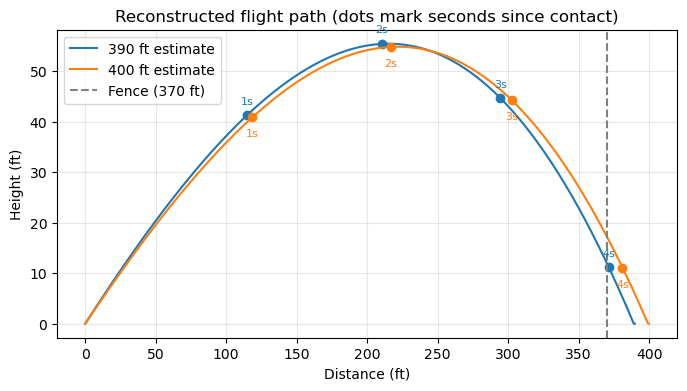

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, (distance_ft, v0, angle, _) in enumerate(results):
    theta = np.radians(angle)
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    xs, ys, ts, x, y, t = [0], [0], [0], 0.0, 0.0, 0.0
    while True:
        vx_rel, vy_rel = vx - headwind, vy
        speed_rel = np.hypot(vx_rel, vy_rel)
        spin_factor = (d_ball / 2) * spin_omega / speed_rel
        Cl = 1 / (2 + 1 / spin_factor)
        drag = 0.5 * Cd * rho * A * speed_rel / m_ball
        lift = 0.5 * Cl * rho * A * speed_rel / m_ball
        vx += (-drag * vx_rel - lift * vy_rel) * 0.01
        vy += (-g - drag * vy_rel + lift * vx_rel) * 0.01
        x += vx * 0.01
        y += vy * 0.01
        t += 0.01
        xs.append(x / FT_TO_M)
        ys.append(max(y / FT_TO_M, 0))
        ts.append(t)
        if y <= 0 and t > 0.02:
            break
    line, = ax.plot(xs, ys, label=f"{distance_ft} ft estimate")

    ts = np.array(ts)
    label_offset = (0, 8) if i == 0 else (0, -14)
    for mark_t in np.arange(1, ts[-1], 1.0):
        idx = np.argmin(np.abs(ts - mark_t))
        ax.plot(xs[idx], ys[idx], "o", color=line.get_color())
        ax.annotate(f"{mark_t:.0f}s", (xs[idx], ys[idx]), textcoords="offset points",
                    xytext=label_offset, ha="center", fontsize=8, color=line.get_color())

ax.axvline(370, color="gray", linestyle="--", label="Fence (370 ft)")
ax.set_xlabel("Distance (ft)")
ax.set_ylabel("Height (ft)")
ax.set_title("Reconstructed flight path (dots mark seconds since contact)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Both estimates now land closer to what a good beer-league swing should look like: a launch angle in the low-to-mid 20s, exit velocity in the high 90s mph, and a swing speed in the upper 60s to low 70s mph. That's a real correction from the previous pass, which used a simpler $C_l \approx S$ lift approximation - checking that approximation against a well-known reference trajectory (100 mph, 29°, 2200 rpm should travel a bit over 400 ft) showed it overshot by close to 40 ft, meaning it was giving backspin more credit for "keeping the ball up" than it deserves. The Sawicki-Hubbard-Stronge model used now matches that reference much more closely, and gives noticeably less lift at these speeds - which pushes the recovered exit velocity and swing speed back up compared to the earlier estimate.

For reference, MLB home runs average around 103 mph exit velocity and 28° launch angle at a pro-level ~2500 rpm of backspin; dialing the backspin down to a more beer-league-realistic 2200 rpm and re-solving lands this swing at a very plausible high-90s mph exit velocity and low-70s mph swing speed - a real, hard-hit line drive rather than either extreme this project has landed on along the way.

Two things are worth actually showing rather than just asserting, though: how much of that movement came from switching lift models versus just adjusting the assumed spin rate, and what these different passes actually looked like as trajectories.

### How Sensitive Is the Estimate to the Backspin Rate?

Holding the Sawicki-Hubbard-Stronge model fixed and sweeping the assumed backspin from 1500 to 3000 rpm - well outside the realistic range for a beer-league swing on either end - shows how much the rpm choice alone actually matters, independent of which lift formula is used:

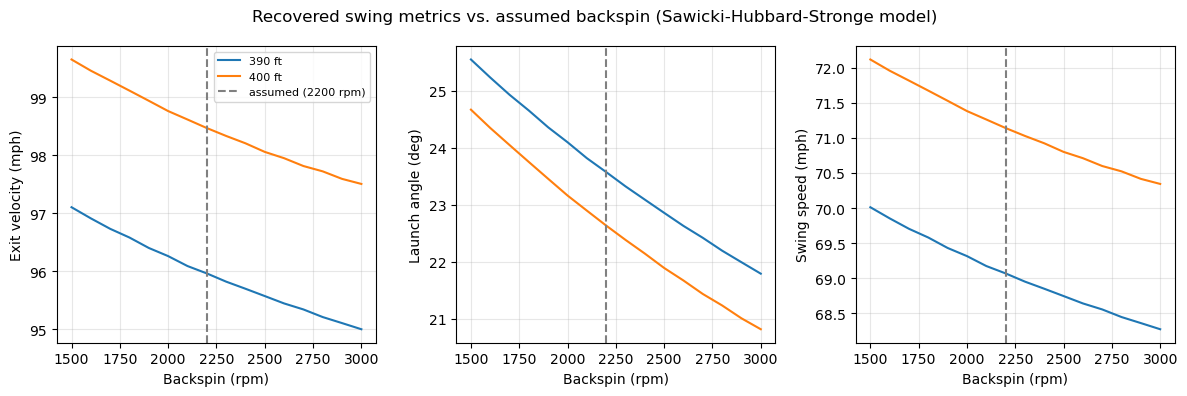

In [8]:
def simulate_trajectory_spin(v0_ms, launch_angle_deg, headwind_ms, spin_omega_val, dt=0.005):
    """Same integration as simulate_trajectory, but with spin rate passed in rather than global."""
    theta = np.radians(launch_angle_deg)
    vx, vy = v0_ms * np.cos(theta), v0_ms * np.sin(theta)
    x, y, t = 0.0, 0.0, 0.0
    while True:
        vx_rel, vy_rel = vx - headwind_ms, vy
        speed_rel = np.hypot(vx_rel, vy_rel)
        spin_factor = (d_ball / 2) * spin_omega_val / speed_rel
        Cl = 1 / (2 + 1 / spin_factor)
        drag = 0.5 * Cd * rho * A * speed_rel / m_ball
        lift = 0.5 * Cl * rho * A * speed_rel / m_ball
        vx += (-drag * vx_rel - lift * vy_rel) * dt
        vy += (-g - drag * vy_rel + lift * vx_rel) * dt
        x += vx * dt
        y += vy * dt
        t += dt
        if y <= 0 and t > dt * 2:
            return x, t


rpm_range = np.arange(1500, 3100, 100)
sensitivity = {distance_ft: {"v0": [], "angle": [], "v_bat": []} for distance_ft, *_ in results}

for distance_ft, *_ in results:
    dist_m = distance_ft * FT_TO_M
    guess = [45, 20]
    for rpm in rpm_range:
        omega = rpm * 2 * np.pi / 60

        def residuals(params, omega=omega):
            v0, angle = params
            dist, t = simulate_trajectory_spin(v0, angle, headwind, omega)
            return [dist - dist_m, t - hang_time]

        v0, angle = fsolve(residuals, guess)
        v_bat = swing_speed_from_exit_velo(v0, v_pitch, M_eff)
        sensitivity[distance_ft]["v0"].append(v0 / MPH_TO_MS)
        sensitivity[distance_ft]["angle"].append(angle)
        sensitivity[distance_ft]["v_bat"].append(v_bat / MPH_TO_MS)
        guess = [v0, angle]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
panel_labels = {"v0": "Exit velocity (mph)", "angle": "Launch angle (deg)", "v_bat": "Swing speed (mph)"}
for ax, key in zip(axes, ["v0", "angle", "v_bat"]):
    for distance_ft, *_ in results:
        ax.plot(rpm_range, sensitivity[distance_ft][key], label=f"{distance_ft} ft")
    ax.axvline(backspin_rpm, color="gray", linestyle="--", label=f"assumed ({backspin_rpm} rpm)")
    ax.set_xlabel("Backspin (rpm)")
    ax.set_ylabel(panel_labels[key])
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Recovered swing metrics vs. assumed backspin (Sawicki-Hubbard-Stronge model)")
plt.tight_layout()
plt.show()

Across that whole range, exit velocity and swing speed move by only about 2 mph, and launch angle by well under 4° - the 2000-2500 rpm debate over what's realistic for a recreational swing barely moves the final answer. That's a reassuring result: it means this estimate doesn't hinge on nailing the exact backspin number, just on using a lift model that's actually calibrated correctly in the first place.

### Comparing the Three Modeling Passes

That calibration is where the real sensitivity lived. Plotting the trajectory this project would have produced at each stage - no spin at all, the over-eager $C_l \approx S$ approximation, and the benchmarked model used above - for the exact same observed 390 ft / 4.25 s flight makes it concrete:

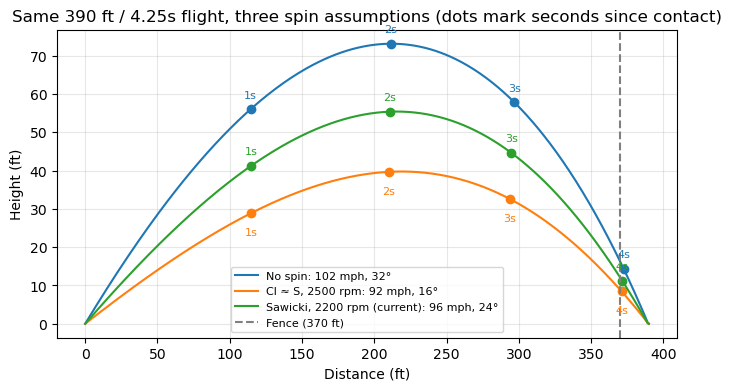

In [9]:
def simulate_variant(v0, angle_deg, headwind_ms, lift_fn, dt=0.01):
    """Like simulate_trajectory, but lift is supplied as a function of relative speed
    so different modeling passes (no spin, Cl=S, Sawicki) can share one integrator."""
    theta = np.radians(angle_deg)
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    x, y, t = 0.0, 0.0, 0.0
    xs, ys, ts = [0.0], [0.0], [0.0]
    while True:
        vx_rel, vy_rel = vx - headwind_ms, vy
        speed_rel = np.hypot(vx_rel, vy_rel)
        drag = 0.5 * Cd * rho * A * speed_rel / m_ball
        lift = lift_fn(speed_rel)
        vx += (-drag * vx_rel - lift * vy_rel) * dt
        vy += (-g - drag * vy_rel + lift * vx_rel) * dt
        x += vx * dt
        y += vy * dt
        t += dt
        xs.append(x / FT_TO_M)
        ys.append(max(y / FT_TO_M, 0))
        ts.append(t)
        if y <= 0 and t > dt * 2:
            return x, t, xs, ys, ts


def lift_none(speed_rel):
    return 0.0


def make_lift_linear(rpm):
    """The Cl = S approximation used in an earlier pass, before benchmarking against a
    known reference trajectory showed it overshoots."""
    omega = rpm * 2 * np.pi / 60
    coef = 0.5 * (d_ball / 2) * omega * rho * A / m_ball
    return lambda speed_rel: coef


def make_lift_sawicki(rpm):
    omega = rpm * 2 * np.pi / 60

    def lift(speed_rel):
        spin_factor = (d_ball / 2) * omega / speed_rel
        Cl = 1 / (2 + 1 / spin_factor)
        return 0.5 * Cl * rho * A * speed_rel / m_ball

    return lift


target_ft = 390
target_m = target_ft * FT_TO_M
variants = [
    ("No spin", lift_none, [45, 32]),
    ("Cl \u2248 S, 2500 rpm", make_lift_linear(2500), [45, 20]),
    ("Sawicki, 2200 rpm (current)", make_lift_sawicki(2200), [45, 20]),
]

fig, ax = plt.subplots(figsize=(8, 4))
label_offsets = [(0, 8), (0, -16), (0, 8)]
for (label, lift_fn, guess), label_offset in zip(variants, label_offsets):
    def residuals(params, lift_fn=lift_fn):
        v0, angle = params
        d, t, _, _, _ = simulate_variant(v0, angle, headwind, lift_fn)
        return [d - target_m, t - hang_time]

    v0, angle = fsolve(residuals, guess)
    _, _, xs, ys, ts = simulate_variant(v0, angle, headwind, lift_fn)
    line, = ax.plot(xs, ys, label=f"{label}: {v0 / MPH_TO_MS:.0f} mph, {angle:.0f}\u00b0")

    ts = np.array(ts)
    for mark_t in np.arange(1, ts[-1], 1.0):
        idx = np.argmin(np.abs(ts - mark_t))
        ax.plot(xs[idx], ys[idx], "o", color=line.get_color())
        ax.annotate(f"{mark_t:.0f}s", (xs[idx], ys[idx]), textcoords="offset points",
                    xytext=label_offset, ha="center", fontsize=8, color=line.get_color())

ax.axvline(370, color="gray", linestyle="--", label="Fence (370 ft)")
ax.set_xlabel("Distance (ft)")
ax.set_ylabel("Height (ft)")
ax.set_title(f"Same {target_ft} ft / {hang_time}s flight, three spin assumptions (dots mark seconds since contact)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

The no-spin trajectory is the tallest and steepest of the three, at a 32° launch angle and a 73 ft apex - without any lift, that's the only way to stay airborne for 4.25 seconds. The over-corrected $C_l \approx S$ pass is the opposite extreme: a low, 16.5° line that floats to just a 40 ft apex, because it assumes backspin is doing far more of the work of staying up than it really does. The benchmarked model lands in between, at a 56 ft apex and a 24° angle - a real, hard-hit line-drive trajectory, not a towering fly ball or an implausible float.

One more thing worth noticing in that same plot: the dots for a given second land at nearly the same distance across all three curves - about 115 ft at 1s, 211 ft at 2s, 295 ft at 3s, and 372 ft at 4s, regardless of which spin assumption produced that trajectory. The endpoints matching is guaranteed by construction (all three are solved to reach the same 390 ft at the same 4.25 s, so their *average* horizontal speed has to agree), but the fact that the whole time profile tracks this closely is a real property of the physics, not just an artifact of those two constraints. The Magnus force is perpendicular to velocity rather than simply "upward," so on the way up it borrows a bit of horizontal speed and on the way down it pays that borrowed speed back; over a roughly symmetric ascent and descent, those two effects largely cancel out. However much lift a given model assumes ends up trading height and hang time against each other, not horizontal distance - so the three arcs are really just three different-height bridges between the same two points in space and time.

## Conclusion

The pieces stack up cleanly: a flight model with drag and a fixed-backspin Magnus lift term gets inverted with a root-finder to recover exit velocity and launch angle, a simplified rigid-bat collision model gets inverted algebraically to recover swing speed, and a bit of ballpark geometry turns a compass-bearing wind report into a usable headwind number. None of it needs more than high-school physics and a nonlinear solver.

It's also worth being honest about where this model would break down or mislead:

- **Fixed backspin assumption.** The Magnus lift term uses a constant, assumed 2200 rpm (a realistic beer-league number, below the ~2500 rpm MLB average) rather than the swing's actual spin rate, which isn't recoverable from just distance and hang time. A sensitivity sweep shows the exact rpm chosen barely matters within a realistic range - the bigger risk is getting the lift *model* itself wrong, which is exactly what happened (and got caught) earlier in this project.
- **Constant drag coefficient and air density.** Both actually vary with altitude, temperature, humidity, and ball speed.
- **Constant coefficient of restitution.** Real bat-ball COR depends on impact speed and the specific bat/ball pair.
- **Idealized taper.** The bat is modeled as a smooth cone with a fixed handle-to-barrel taper ratio, not the actual measured profile of a TX73, and "balance factor" is a rough stand-in for a real moment-of-inertia measurement.
- **Crosswind ignored.** It affects where the ball lands sideways, not how far it carries or how long it hangs, so leaving it out doesn't bias the distance/time solve - but it does mean this model has nothing to say about how far off the labeled hit direction the ball actually drifted.

None of that makes this a replacement for a TrackMan. It does turn "I think it went about 390-400 feet and hung around four and a quarter seconds" into a genuinely informative estimate - which is exactly the kind of thing worth having for a beer-league home run nobody was tracking with radar.